# Notebook 4 - Ejecucion y Costes
Backtesting LONG-only realista de la estrategia Momentum de Notebook 3.

## Configuracion

In [25]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.fs as fs

sns.set(style="whitegrid", context="notebook")

START_DATE = pd.Timestamp("2015-01-01")
INITIAL_CAPITAL = 250000.0
TOP_N = 20
TARGET_W = 1.0 / TOP_N
FEE_RATE = 0.0023
MIN_FEE = 23.0
BENCH = "SPY"

# Control de rotacion: 1=mensual, 3=trimestral, 6=semestral
REBALANCE_EVERY_N_MONTHS = 6

PRICE_PATH_HINTS = [
    "data/processed/prices.parquet",
    "data/raw/sp500_history.parquet",
    "notebooks/data/processed/prices.parquet",
    "notebooks/data/raw/sp500_history.parquet",
    r"C:\Users\alons\Desktop\Pr?ctica 7\sp500_history.parquet",
    r"C:\Users\alons\Desktop\Practica 7\sp500_history.parquet",
]

SELECTION_PATH_HINTS = [
    "outputs/selected_top20_by_rebalance.csv",
    "outputs/selected_20_each_rebalance.csv",
    "notebooks/outputs/selected_top20_by_rebalance.csv",
    "notebooks/outputs/selected_20_each_rebalance.csv",
    "selected_top20_by_rebalance.csv",
]

# Parametros canonicos del FIX (backtest principal)
MAX_FEE_PCT = 0.01
# Evita quedar 100% en cash si el filtro de notional bloquea TODAS las compras de un rebalance.
ALLOW_MIN_NOTIONAL_RELAX_IF_BLOCKED = True
# Evita cash negativo cuando una venta forzosa muy pequena no cubre fee minimo.
CLIP_FORCED_EXIT_FEE_TO_AVAILABLE_CASH = True
MTM_FFILL_LIMIT = 1
MAX_POSITION_WEIGHT = 0.15
ENFORCE_WEIGHT_CAP_DAILY = True

# Control anti-outliers OPEN/CLOSE. Debe ser > 1.
MAX_OPEN_CLOSE_RATIO = 4.0
# Si True: aborta el backtest al detectar anomalia OPEN/CLOSE en salida (evita equity contaminada).
HARD_FAIL_ON_OPEN_CLOSE_ANOMALY = False
# Si True: ante anomalia OPEN/CLOSE en salida, no ejecuta ese exit (evita PnL ficticio).
SKIP_EXIT_ON_OPEN_CLOSE_ANOMALY = True


## Funciones base

In [26]:
def compute_commission(notional, rate=0.0023, min_fee=23.0):
    n = float(abs(notional))
    if n <= 0:
        return 0.0
    return max(rate * n, min_fee)


def get_month_end_dates(index):
    idx = pd.DatetimeIndex(index).sort_values().unique()
    s = pd.Series(idx, index=idx)
    out = s.groupby(s.index.to_period("M")).max().sort_values()
    return pd.DatetimeIndex(out.values)


def compute_metrics(equity, benchmark=None, freq=252):
    eq = pd.Series(equity).dropna().sort_index()
    if len(eq) < 2:
        return {}
    r = eq.pct_change().dropna()
    yrs = len(r) / float(freq)
    cagr = (eq.iloc[-1] / eq.iloc[0]) ** (1 / yrs) - 1 if yrs > 0 else np.nan
    vol = r.std(ddof=0) * np.sqrt(freq)
    sharpe = (r.mean() / r.std(ddof=0) * np.sqrt(freq)) if r.std(ddof=0) > 0 else np.nan
    dd = eq / eq.cummax() - 1
    out = {
        "total_return": eq.iloc[-1] / eq.iloc[0] - 1,
        "cagr": cagr,
        "vol": vol,
        "sharpe": sharpe,
        "max_drawdown": dd.min(),
    }
    if benchmark is not None:
        b = pd.Series(benchmark).dropna().sort_index()
        a = pd.concat([eq, b], axis=1, join="inner").dropna()
        if len(a) > 2:
            rs = a.iloc[:, 0].pct_change().dropna()
            rb = a.iloc[:, 1].pct_change().dropna()
            x = pd.concat([rs, rb], axis=1).dropna()
            if len(x) > 2:
                out["alpha_daily_mean"] = (x.iloc[:, 0] - x.iloc[:, 1]).mean()
                vb = np.var(x.iloc[:, 1])
                out["beta"] = np.cov(x.iloc[:, 0], x.iloc[:, 1])[0, 1] / vb if vb > 0 else np.nan
    return out


def monte_carlo_monkeys(monthly_returns, n_monos=2000, chunk_size=6, fee_rate=0.0023):
    r = pd.Series(monthly_returns).dropna().astype(float)
    if len(r) < max(24, chunk_size * 2):
        raise ValueError("No hay suficientes retornos mensuales para Monte Carlo por bloques.")
    v = r.values
    n = len(v)
    starts = np.arange(n - chunk_size + 1)
    drag = fee_rate / 12.0
    rows = []
    for _ in range(int(n_monos)):
        path = []
        while len(path) < n:
            st = np.random.choice(starts)
            path.extend(v[st:st + chunk_size].tolist())
        path = np.array(path[:n]) - drag
        wealth = np.cumprod(1 + path)
        yrs = n / 12.0
        cagr = wealth[-1] ** (1 / yrs) - 1 if yrs > 0 and wealth[-1] > 0 else np.nan
        vol = np.std(path, ddof=0) * np.sqrt(12)
        sharpe = (np.mean(path) / np.std(path, ddof=0) * np.sqrt(12)) if np.std(path, ddof=0) > 0 else np.nan
        rows.append((wealth[-1] - 1, cagr, vol, sharpe))
    return pd.DataFrame(rows, columns=["total_return", "cagr", "vol", "sharpe"])

## Carga y adapter de precios (OPEN/CLOSE)

In [27]:
def _scan_files(roots):
    lfs = fs.LocalFileSystem()
    out, seen = [], set()
    for root in roots:
        try:
            info = lfs.get_file_info(root)
            if info.type == fs.FileType.File:
                if root not in seen:
                    out.append(root)
                    seen.add(root)
                continue
        except Exception:
            pass
        try:
            infos = lfs.get_file_info(fs.FileSelector(root, recursive=True))
        except Exception:
            continue
        for i in infos:
            if i.type != fs.FileType.File:
                continue
            p = i.path
            pl = p.lower()
            if pl.endswith('.parquet') or pl.endswith('.csv'):
                if 'selected_top20_by_rebalance' in pl:
                    continue
                if p not in seen:
                    out.append(p)
                    seen.add(p)
    return out


def _read_any(path):
    try:
        if path.lower().endswith('.parquet'):
            return pq.read_table(path).to_pandas()
        if path.lower().endswith('.csv'):
            return pd.read_csv(path)
    except Exception:
        return None
    return None


def _canon(c):
    return str(c).strip().lower().replace(' ', '_').replace('-', '_').replace('.', '_')


def _find_col(cols, candidates):
    cmap = {_canon(c): c for c in cols}
    for c in candidates:
        if c in cmap:
            return cmap[c]
    return None


def _extract_field(df, field):
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None

    # MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        l0 = pd.Index([_canon(c) for c in df.columns.get_level_values(0)])
        l1 = pd.Index([_canon(c) for c in df.columns.get_level_values(1)])

        keys = [field]
        if field == 'close':
            keys = ['adj_close', 'adj close', 'close']
        if field == 'unadjusted_close':
            keys = ['unadjusted_close', 'unadjusted close']

        for key in keys:
            k = _canon(key)
            if k in l0.values:
                out = df.xs(k, axis=1, level=0)
                out.columns = [str(c).upper() for c in out.columns]
                return out.sort_index()
            if k in l1.values:
                out = df.xs(k, axis=1, level=1)
                out.columns = [str(c).upper() for c in out.columns]
                return out.sort_index()

    # Long format
    date_col = _find_col(df.columns, ['date', 'datetime', 'timestamp', 'fecha'])
    ticker_col = _find_col(df.columns, ['ticker', 'symbol', 'asset', 'activo'])
    field_col = _find_col(df.columns, [field, field.replace('_', ' ')])

    if field_col is None and field == 'close':
        field_col = _find_col(df.columns, ['adj_close', 'adj close', 'close'])

    if date_col is not None and ticker_col is not None and field_col is not None:
        x = df[[date_col, ticker_col, field_col]].copy()
        x[date_col] = pd.to_datetime(x[date_col], errors='coerce')
        x[ticker_col] = x[ticker_col].astype(str).str.upper()
        x = x.dropna(subset=[date_col, ticker_col, field_col])
        out = x.pivot_table(index=date_col, columns=ticker_col, values=field_col, aggfunc='last')
        return out.sort_index()

    # Flat wide columns
    x = df.copy()
    if not isinstance(x.index, pd.DatetimeIndex):
        dcol = _find_col(x.columns, ['date', 'datetime', 'timestamp', 'fecha'])
        if dcol is None:
            return None
        x[dcol] = pd.to_datetime(x[dcol], errors='coerce')
        x = x.dropna(subset=[dcol]).set_index(dcol)

    out = pd.DataFrame(index=x.index)
    for c in x.columns:
        n = _canon(c)
        parts = [p for p in n.split('_') if p]
        if len(parts) < 2:
            continue

        tk = None
        if field in ['open', 'high', 'low', 'close', 'adj_close']:
            if parts[-1] == field:
                tk = '_'.join(parts[:-1]).upper()
            elif parts[0] == field:
                tk = '_'.join(parts[1:]).upper()
            elif field in ['close', 'adj_close'] and parts[-2:] == ['adj', 'close']:
                tk = '_'.join(parts[:-2]).upper()
        elif field == 'unadjusted_close':
            if parts[-2:] == ['unadjusted', 'close']:
                tk = '_'.join(parts[:-2]).upper()

        if tk and len(tk) > 0:
            out[tk] = pd.to_numeric(x[c], errors='coerce')

    if out.shape[1] == 0:
        return None
    return out.sort_index()


def _align_panels(panels):
    all_idx = pd.DatetimeIndex(sorted(set().union(*[set(v.index) for v in panels.values() if v is not None])))
    all_cols = sorted(set().union(*[set(v.columns) for v in panels.values() if v is not None]))

    out = {}
    for k, v in panels.items():
        if v is None:
            out[k] = pd.DataFrame(index=all_idx, columns=all_cols, dtype=float)
        else:
            x = v.copy()
            x.index = pd.to_datetime(x.index, errors='coerce')
            x = x[~x.index.isna()].sort_index()
            x = x[~x.index.duplicated(keep='last')]
            x = x.replace([np.inf, -np.inf], np.nan)
            x.columns = [str(c).upper() for c in x.columns]
            out[k] = x.reindex(index=all_idx, columns=all_cols)
    return out


def _report_ratio_extremes(ratio_df, title):
    s = ratio_df.stack().replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) == 0:
        print(f'{title}: sin datos')
        return pd.DataFrame()
    print(title)
    print(s.quantile([0.01, 0.5, 0.99, 0.999]))

    ext = s.rename('ratio').to_frame()
    ext['abs_log'] = np.abs(np.log(ext['ratio'].replace(0, np.nan)))
    ext = ext.replace([np.inf, -np.inf], np.nan).dropna().sort_values('abs_log', ascending=False).head(20)
    print('Top 20 extremos:')
    display(ext)
    return ext


def _build_consistent_prices_from_raw(df):
    panels = {
        'open_raw': _extract_field(df, 'open'),
        'high_raw': _extract_field(df, 'high'),
        'low_raw': _extract_field(df, 'low'),
        'close_raw': _extract_field(df, 'close'),
        'adj_close': _extract_field(df, 'adj_close'),
        'unadjusted_close': _extract_field(df, 'unadjusted_close'),
    }
    panels = _align_panels(panels)

    open_raw = panels['open_raw']
    close_raw = panels['close_raw']
    adj_close = panels['adj_close']
    unadj_close = panels['unadjusted_close']

    # close usado
    has_adj = adj_close.notna().sum().sum() > 0
    close_used = adj_close.copy() if has_adj else close_raw.copy()

    factor = None
    factor_source = None
    mode = None

    if has_adj and open_raw.notna().sum().sum() > 0:
        if unadj_close.notna().sum().sum() > 0:
            factor = (adj_close / unadj_close).replace([np.inf, -np.inf], np.nan)
            factor_source = 'adj_close / unadjusted_close'
        elif close_raw.notna().sum().sum() > 0:
            factor = (adj_close / close_raw).replace([np.inf, -np.inf], np.nan)
            factor_source = 'adj_close / close_raw'

        if factor is not None:
            raw_factor = factor.copy()
            low_q = raw_factor.stack().quantile(0.001) if raw_factor.stack().notna().sum() > 0 else np.nan
            hi_q = raw_factor.stack().quantile(0.999) if raw_factor.stack().notna().sum() > 0 else np.nan
            print('Factor source:', factor_source, '| q0.1%:', low_q, 'q99.9%:', hi_q)

            clipped = factor.clip(lower=0.1, upper=10.0)
            clipped_outliers = ((factor < 0.1) | (factor > 10.0)).stack().fillna(False)
            n_clip = int(clipped_outliers.sum())
            if n_clip > 0:
                print(f'WARNING: factores fuera de [0.1,10] -> {n_clip} observaciones (clip aplicado).')

            open_used = open_raw * clipped
            mode = 'adjusted_consistent'
        else:
            open_used = open_raw.copy()
            close_used = close_raw.copy()
            mode = 'raw_consistent_fallback'
    else:
        # sin base fiable para ajustar open -> mantener todo en no ajustado
        open_used = open_raw.copy()
        if close_raw.notna().sum().sum() > 0:
            close_used = close_raw.copy()
            mode = 'raw_consistent'
        else:
            open_used = close_used.copy()
            mode = 'close_only_fallback'

    ratio = (open_used / close_used).replace([np.inf, -np.inf], np.nan)
    _report_ratio_extremes(ratio, 'Chequeo open_used / close_used')

    return {
        'open_used': open_used,
        'close_used': close_used,
        'open_raw': open_raw,
        'close_raw': close_raw,
        'adj_close': adj_close,
        'unadjusted_close': unadj_close,
        'scale_mode': mode,
        'factor_source': factor_source,
    }


def load_prices():
    dynamic_paths = []
    if 'PARQUET_PATH' in globals() and isinstance(globals()['PARQUET_PATH'], str):
        dynamic_paths.append(globals()['PARQUET_PATH'])

    # fallback robusto: buscar por nombre en Desktop
    try:
        infos = fs.LocalFileSystem().get_file_info(fs.FileSelector(r'C:\Users\alons\Desktop', recursive=True))
        for info in infos:
            if info.type == fs.FileType.File and info.path.lower().endswith('sp500_history.parquet'):
                dynamic_paths.append(info.path)
    except Exception:
        pass

    paths = dynamic_paths + PRICE_PATH_HINTS + _scan_files(['data', 'notebooks/data'])

    seen, ordered = set(), []
    for p in paths:
        if p not in seen:
            ordered.append(p)
            seen.add(p)

    best = (None, None, None, None, -1)
    for p in ordered:
        raw = _read_any(p)
        if raw is None or not isinstance(raw, pd.DataFrame) or raw.empty:
            continue

        built = _build_consistent_prices_from_raw(raw)
        op = built['open_used']
        cl = built['close_used']

        score = cl.shape[0] * max(1, cl.shape[1])
        if cl.shape[1] >= TOP_N and cl.shape[0] >= 260:
            print('Fuente precios:', p)
            print('Scale mode:', built['scale_mode'])
            return op, cl, built, p

        if score > best[4]:
            best = (op, cl, built, p, score)

    if best[0] is not None:
        print('Fuente precios (mejor disponible):', best[3])
        print('Scale mode:', best[2]['scale_mode'])
        return best[0], best[1], best[2], best[3]

    raise FileNotFoundError('No se pudo leer una fuente de precios valida. Ejecuta Notebook 1 o define PARQUET_PATH a sp500_history.parquet.')


open_px, close_px, price_panels, price_source = load_prices()

# FIX canonico: unificar escala OPEN/HIGH/LOW a CLOSE de forma incondicional.
close_bt = close_px.copy()
open_bt = open_px.copy()

open_raw_panel = price_panels.get('open_raw') if isinstance(price_panels, dict) else None
unadj_panel = price_panels.get('unadjusted_close') if isinstance(price_panels, dict) else None
close_raw_panel = price_panels.get('close_raw') if isinstance(price_panels, dict) else None

if isinstance(open_raw_panel, pd.DataFrame) and open_raw_panel.notna().sum().sum() > 0:
    open_raw_aligned = open_raw_panel.reindex(index=close_bt.index, columns=close_bt.columns)

    adj_factor_fix = None
    if isinstance(unadj_panel, pd.DataFrame) and unadj_panel.notna().sum().sum() > 0:
        unadj_aligned = unadj_panel.reindex(index=close_bt.index, columns=close_bt.columns)
        adj_factor_fix = (close_bt / unadj_aligned).replace([np.inf, -np.inf], np.nan)

    if isinstance(close_raw_panel, pd.DataFrame) and close_raw_panel.notna().sum().sum() > 0:
        close_raw_aligned = close_raw_panel.reindex(index=close_bt.index, columns=close_bt.columns)
        adj_factor_alt = (close_bt / close_raw_aligned).replace([np.inf, -np.inf], np.nan)
        if adj_factor_fix is None:
            adj_factor_fix = adj_factor_alt
        else:
            adj_factor_fix = adj_factor_fix.where(adj_factor_fix.notna(), adj_factor_alt)

    if adj_factor_fix is not None:
        open_bt = (open_raw_aligned * adj_factor_fix).replace([np.inf, -np.inf], np.nan)
        open_bt = open_bt.where(open_bt.notna(), open_raw_aligned)
        open_bt = open_bt.where(open_bt.notna(), open_px.reindex(index=close_bt.index, columns=close_bt.columns))

# El notebook usa open_px/close_px como entradas oficiales del motor.
open_px = open_bt.copy()
close_px = close_bt.copy()
trading_index = close_px.index.sort_values().unique()

ratio_scale = (open_px / close_px).stack().replace([np.inf, -np.inf], np.nan).dropna()
if len(ratio_scale) > 0:
    ratio_q = ratio_scale.quantile([0.001, 0.01, 0.5, 0.99, 0.999])
    print('Quantiles OPEN/CLOSE tras FIX canonico:')
    print(ratio_q)

print('Rango fechas (full, incluye warm-up):', trading_index.min(), '->', trading_index.max())
print('#tickers:', close_px.shape[1])
print('Ejemplo columnas:', close_px.columns[:12].tolist())
print('%missing close usado (top10):')
display((close_px.isna().mean() * 100).sort_values(ascending=False).head(10).to_frame('missing_%'))
print('Scale mode final:', price_panels['scale_mode'])
print('Factor source:', price_panels['factor_source'])
print('FIX canonico aplicado al flujo principal: OPEN alineado a escala CLOSE.')


Chequeo open_used / close_used
0.010    0.934579
0.500    1.000000
0.990    1.068662
0.999    1.166822
dtype: float64
Top 20 extremos:


,,ratio,abs_log
2024-10-29,SBNY,0.000296,8.124150
2025-11-06,SBNY,0.000469,7.665441
2024-02-23,RADCQ-202409,0.000588,7.438384
2024-06-04,RADCQ-202409,0.000800,7.130899
2024-06-10,RADCQ-202409,0.000833,7.090077
2024-03-21,RADCQ-202409,0.001111,6.802395
2024-03-12,RADCQ-202409,0.001667,6.396930
2023-12-20,ENDPQ-202405,0.001667,6.396930
2024-04-25,ENDPQ-202405,0.001667,6.396930
2024-06-13,RADCQ-202409,0.002000,6.214608


Fuente precios: C:/Users/alons/Desktop/Práctica 7/sp500_history.parquet
Scale mode: raw_consistent
Quantiles OPEN/CLOSE tras FIX canonico:
0.001       0.008245
0.010       0.021799
0.500       0.733171
0.990      10.199476
0.999    1394.847068
dtype: float64
Rango fechas (full, incluye warm-up): 1990-01-02 00:00:00 -> 2026-01-30 00:00:00
#tickers: 1289
Ejemplo columnas: ['A', 'AABA-201910', 'AAL', 'AAL-199702', 'AAMRQ-201312', 'AAP', 'AAPL', 'AAV-199901', 'ABBV', 'ABI-200811', 'ABKFQ-201304', 'ABMD-202212']
%missing close usado (top10):


,missing_%
HIA-199002,99.702872
Q,99.273688
SOLS,99.218664
GNN-199006,98.657423
GHC-199308,98.514361
NRT-199008,98.316276
PHL-199008,98.206229
GRL-199008,98.206229
SOV-199008,98.129196
H-200704,98.008144


Scale mode final: raw_consistent
Factor source: None
FIX canonico aplicado al flujo principal: OPEN alineado a escala CLOSE.


## Carga de selecciones del Notebook 3

In [28]:
def load_selections():
    paths = SELECTION_PATH_HINTS + _scan_files(["outputs", "notebooks/outputs", ".", "..", "notebooks"])
    seen, ordered = set(), []
    for p in paths:
        if p not in seen:
            ordered.append(p); seen.add(p)

    sel, src = None, None
    for p in ordered:
        if not p.lower().endswith(".csv"):
            continue
        df = _read_any(p)
        if df is None or len(df) == 0:
            continue
        cols = [str(c).strip().lower() for c in df.columns]
        df.columns = cols

        dcol = next((c for c in ["rebalance_date", "date", "fecha"] if c in cols), None)
        tcol = next((c for c in ["ticker", "symbol", "asset", "activo"] if c in cols), None)

        if dcol is not None and tcol is not None:
            x = df.copy()
            x[dcol] = pd.to_datetime(x[dcol], errors="coerce")
            x[tcol] = x[tcol].astype(str).str.upper()
            x = x.dropna(subset=[dcol, tcol])
            if "rank" not in x.columns:
                if "score" in x.columns:
                    x = x.sort_values([dcol, "score", tcol], ascending=[True, False, True])
                else:
                    x = x.sort_values([dcol, tcol], ascending=[True, True])
                x["rank"] = x.groupby(dcol).cumcount() + 1
            keep = [dcol, tcol, "rank"] + [c for c in ["score", "z6", "z12"] if c in x.columns]
            x = x[keep].rename(columns={dcol: "rebalance_date", tcol: "ticker"})
            sel, src = x, p
            break

    if sel is None or len(sel) == 0:
        raise FileNotFoundError("No se pudo cargar el CSV de selecciones (Notebook 3).")

    sel = sel[sel["ticker"] != "GLD"].copy()
    sel = sel.sort_values(["rebalance_date", "rank", "ticker"], ascending=[True, True, True])
    return sel, src


selections_long, selection_source = load_selections()
print("Fuente selecciones:", selection_source)
print("Rango selecciones:", selections_long["rebalance_date"].min(), "->", selections_long["rebalance_date"].max())
print("Fechas unicas:", selections_long["rebalance_date"].nunique())
display(selections_long.head(20))

Fuente selecciones: outputs/selected_top20_by_rebalance.csv
Rango selecciones: 2015-01-30 00:00:00 -> 2026-01-30 00:00:00
Fechas unicas: 133


,rebalance_date,ticker,rank,score,z6,z12
0,2015-01-30,SWKS,1,3.027822,2.217654,3.837991
1,2015-01-30,ENPH,2,2.929470,2.638473,3.220467
2,2015-01-30,LUV,3,2.777000,2.314166,3.239834
3,2015-01-30,AXON,4,2.716590,3.658595,1.774586
4,2015-01-30,PANW,5,2.406400,1.857479,2.955321
5,2015-01-30,UAL,6,2.271787,2.487742,2.055833
6,2015-01-30,EW,7,2.219309,1.945133,2.493485
7,2015-01-30,SMCI,8,2.123862,1.523122,2.724602
8,2015-01-30,AVGO,9,2.055842,1.630196,2.481487
9,2015-01-30,RCL,10,2.023139,1.986960,2.059318


## Fechas de rebalanceo (intersecci?n calendario real + CSV)

In [29]:
month_end_dates = get_month_end_dates(trading_index)
month_end_map = pd.Series(month_end_dates, index=month_end_dates.to_period("M"))

s = selections_long.copy()
s["period"] = s["rebalance_date"].dt.to_period("M")
latest_signal = s.groupby("period")["rebalance_date"].max()

selections_by_rebalance = {}
for period, dsel in latest_signal.items():
    if period not in month_end_map.index:
        continue
    dreb = month_end_map.loc[period]
    sub = s[(s["period"] == period) & (s["rebalance_date"] == dsel)].copy()
    sub = sub.sort_values(["rank", "ticker"])
    tickers = []
    for tk in sub["ticker"].tolist():
        if tk not in tickers and tk in close_px.columns:
            tickers.append(tk)
    selections_by_rebalance[dreb] = tickers[:TOP_N]

rebalance_dates = sorted([d for d in selections_by_rebalance.keys() if d in set(month_end_dates) and d in set(trading_index)])

print("#month_end dataset:", len(month_end_dates))
print("#rebalance final:", len(rebalance_dates))
print("Primeras fechas:", rebalance_dates[:8])
if len(rebalance_dates) == 0:
    raise ValueError("No hay fechas de rebalanceo validas.")

#month_end dataset: 433
#rebalance final: 133
Primeras fechas: [Timestamp('2015-01-30 00:00:00'), Timestamp('2015-02-27 00:00:00'), Timestamp('2015-03-31 00:00:00'), Timestamp('2015-04-30 00:00:00'), Timestamp('2015-05-29 00:00:00'), Timestamp('2015-06-30 00:00:00'), Timestamp('2015-07-31 00:00:00'), Timestamp('2015-08-31 00:00:00')]


## Motor de backtesting (sin look-ahead)

In [30]:
def _is_valid_price(x):
    return pd.notna(x) and np.isfinite(x) and float(x) > 0


def _get_px_open(op, cl, ticker, d):
    p = op.at[d, ticker] if (d in op.index and ticker in op.columns) else np.nan
    if _is_valid_price(p):
        return float(p), 'OPEN_D'
    return np.nan, 'NO_PRICE'


def _get_px_close(cl, ticker, d):
    p = cl.at[d, ticker] if (d in cl.index and ticker in cl.columns) else np.nan
    if _is_valid_price(p):
        return float(p), 'CLOSE_D'
    return np.nan, 'NO_PRICE'


def _normalize_selections_to_dataset_month_end(selections, trading_index, top_n=20):
    month_ends = get_month_end_dates(trading_index)
    month_end_map = pd.Series(month_ends, index=month_ends.to_period('M'))

    out = {}
    for d, tickers in selections.items():
        d = pd.Timestamp(d)
        period = d.to_period('M')
        if period not in month_end_map.index:
            continue
        d_me = month_end_map.loc[period]

        uniq = []
        for tk in tickers:
            t = str(tk).upper()
            if t == 'GLD':
                continue
            if t not in uniq:
                uniq.append(t)
        out[d_me] = uniq[:top_n]

    return dict(sorted(out.items(), key=lambda x: x[0]))


def _month_id(ts):
    ts = pd.Timestamp(ts)
    return ts.year * 12 + ts.month


def _build_execution_schedule(eligible_rebalances, n_months):
    if len(eligible_rebalances) == 0:
        return []
    n = int(n_months)
    if n <= 1:
        return list(eligible_rebalances)

    out = []
    anchor = eligible_rebalances[0]
    anchor_id = _month_id(anchor)
    for d in eligible_rebalances:
        if (_month_id(d) - anchor_id) % n == 0:
            out.append(d)
    return out


def backtest_momentum_execution(prices_open, prices_close, selections,
                                start_date='2015-01-01', initial_capital=250000.0,
                                top_n=20, fee_rate=0.0023, min_fee=23.0,
                                rebalance_every_n_months=1, max_fee_pct=0.01,
                                mtm_ffill_limit=1, max_position_weight=0.15,
                                enforce_weight_cap_daily=True, max_open_close_ratio=3.0,
                                allow_min_notional_relax_if_blocked=True,
                                clip_forced_exit_fee_to_available_cash=True,
                                hard_fail_on_open_close_anomaly=False,
                                skip_exit_on_open_close_anomaly=True):
    op_full = prices_open.sort_index().copy()
    cl_full = prices_close.sort_index().copy()

    start_date = pd.Timestamp(start_date)

    trading_index_full = cl_full.index.sort_values().unique()
    selections_norm = _normalize_selections_to_dataset_month_end(selections, trading_index_full, top_n=top_n)
    rebalance_dates_all = sorted(selections_norm.keys())

    eligible_rebalances = [d for d in rebalance_dates_all if d >= start_date]
    execution_rebalances = _build_execution_schedule(eligible_rebalances, rebalance_every_n_months)
    execution_set = set(execution_rebalances)

    print('Frecuencia rebalanceo (meses):', rebalance_every_n_months)
    print('Rebalances elegibles:', len(eligible_rebalances), '| Rebalances ejecutados:', len(execution_rebalances))

    dates = trading_index_full[trading_index_full >= start_date]
    op = op_full.reindex(index=dates, columns=cl_full.columns)
    cl = cl_full.reindex(index=dates, columns=cl_full.columns)
    if mtm_ffill_limit is None:
        cl_mtm = cl.copy()
    else:
        cl_mtm = cl.ffill(limit=int(mtm_ffill_limit))

    min_notional = (min_fee / max_fee_pct) if (max_fee_pct is not None and max_fee_pct > 0) else 0.0
    max_position_weight = float(max_position_weight) if (max_position_weight is not None) else None
    max_open_close_ratio = float(max_open_close_ratio) if (max_open_close_ratio is not None) else None
    if (max_open_close_ratio is not None) and (max_open_close_ratio <= 1.0):
        raise ValueError('max_open_close_ratio debe ser > 1.0 (ejemplo: 1.2 para ?20%).')

    positions = {}
    cash = float(initial_capital)

    eq_rows = []
    tr_rows = []
    wt_rows = []
    event_rows = []

    prev_date = None

    def _mtm_value(mark_date, exec_px_override=None):
        pv = 0.0
        for t, sh in positions.items():
            if sh <= 0:
                continue
            if exec_px_override is not None and t in exec_px_override:
                p = exec_px_override[t]
            else:
                p = cl_mtm.at[mark_date, t] if (mark_date in cl_mtm.index and t in cl_mtm.columns) else np.nan
            if _is_valid_price(p):
                pv += sh * float(p)
        return pv

    def equity_now(d):
        pv = _mtm_value(d)
        return cash + pv, pv

    def equity_trade_log(d, exec_px_override=None):
        mark_date = prev_date if prev_date is not None else d
        pv = _mtm_value(mark_date, exec_px_override=exec_px_override)
        return cash + pv, pv

    def _get_px_open_filtered(ticker, d):
        px_open, src_open = _get_px_open(op, cl, ticker, d)
        if not _is_valid_price(px_open):
            return np.nan, src_open

        # Alerta anti-outlier: OPEN desalineado vs CLOSE del mismo dia.
        # Regla obligatoria: la salida sigue ejecutandose a OPEN.
        if src_open == 'OPEN_D' and (max_open_close_ratio is not None):
            px_close_d, _ = _get_px_close(cl, ticker, d)
            if _is_valid_price(px_close_d):
                ratio = float(px_open) / float(px_close_d)
                lo = 1.0 / float(max_open_close_ratio)
                hi = float(max_open_close_ratio)
                if ratio < lo or ratio > hi:
                    event_rows.append({
                        'date': d,
                        'ticker': ticker,
                        'event': 'open_close_ratio_anomaly_exit_alert',
                        'open_px': float(px_open),
                        'close_px': float(px_close_d),
                        'open_close_ratio': float(ratio),
                        'ratio_low': float(lo),
                        'ratio_high': float(hi),
                    })
                    if hard_fail_on_open_close_anomaly:
                        raise ValueError(
                            f"OPEN/CLOSE anomaly en exit: {ticker} {pd.Timestamp(d).date()} "
                            f"open={float(px_open):.6f}, close={float(px_close_d):.6f}, ratio={float(ratio):.6f}, "
                            f"umbral=[{float(lo):.6f},{float(hi):.6f}]"
                        )
                    if skip_exit_on_open_close_anomaly:
                        event_rows.append({
                            'date': d,
                            'ticker': ticker,
                            'event': 'skip_exit_open_close_anomaly',
                            'open_px': float(px_open),
                            'close_px': float(px_close_d),
                            'open_close_ratio': float(ratio),
                            'ratio_low': float(lo),
                            'ratio_high': float(hi),
                        })
                        return np.nan, 'OPEN_ANOMALY_SKIP'

        return float(px_open), src_open

    for d in dates:
        day_orders = 0
        did_rebalance = 0
        day_turnover = 0.0

        # pesos pre-trade para turnover
        eq_pre, pv_pre = equity_now(d)
        old_w = {}
        if eq_pre > 0:
            for t, sh in positions.items():
                if sh <= 0:
                    continue
                p = cl_mtm.at[d, t] if (d in cl_mtm.index and t in cl_mtm.columns) else np.nan
                if _is_valid_price(p):
                    old_w[t] = (sh * float(p)) / eq_pre

        if d in execution_set:
            target_all = [t for t in selections_norm.get(d, []) if t in cl.columns][:top_n]
            did_rebalance = 1

            held = [t for t, sh in positions.items() if sh > 1e-12]
            exits = [t for t in held if t not in set(target_all)]

            # A) sells de salida a OPEN usado
            for t in exits:
                sh = positions.get(t, 0.0)
                if sh <= 0:
                    continue
                px, src = _get_px_open_filtered(t, d)
                if not _is_valid_price(px):
                    event_rows.append({'date': d, 'ticker': t, 'event': 'skip_exit_no_price'})
                    continue

                notional = sh * px
                fee_raw = compute_commission(notional, rate=fee_rate, min_fee=min_fee)
                fee = float(fee_raw)
                if clip_forced_exit_fee_to_available_cash:
                    max_fee_affordable = max(0.0, float(cash) + float(notional))
                    fee = min(float(fee_raw), float(max_fee_affordable))
                    if fee + 1e-12 < float(fee_raw):
                        event_rows.append({
                            'date': d,
                            'ticker': t,
                            'event': 'forced_exit_fee_capped_to_avoid_negative_cash',
                            'fee_raw': float(fee_raw),
                            'fee_used': float(fee),
                            'notional': float(notional),
                            'cash_before': float(cash),
                        })

                cash += notional - fee
                positions[t] = 0.0
                day_orders += 1

                eq_a, _ = equity_trade_log(d, exec_px_override={t: float(px)})
                tr_rows.append({
                    'date': d,
                    'ticker': t,
                    'side': 'SELL',
                    'price': float(px),
                    'shares': float(sh),
                    'notional': float(notional),
                    'fee': float(fee),
                    'cash_after': float(cash),
                    'equity_after': float(eq_a),
                    'price_source': src,
                    'reason': 'exit',
                })

            # B) rebalance de stayers + entries al CLOSE usado
            target_weight = 1.0 / top_n

            # Valorizacion explicita al CLOSE del dia para definir desired_value.
            close_today = {}
            universe_today = set(target_all) | {t for t, sh in positions.items() if sh > 0}
            for t in universe_today:
                px_close, _ = _get_px_close(cl, t, d)
                if _is_valid_price(px_close):
                    close_today[t] = float(px_close)

            tradable_target = []
            for t in target_all:
                if t in close_today:
                    tradable_target.append(t)
                else:
                    event_rows.append({'date': d, 'ticker': t, 'event': 'skip_target_no_close'})

            equity_for_target = float(cash)
            current_value = {}
            for t, sh in positions.items():
                if sh <= 0:
                    continue
                px_close = close_today.get(t, np.nan)
                if _is_valid_price(px_close):
                    pos_val = sh * px_close
                    current_value[t] = pos_val
                    equity_for_target += pos_val

            desired_value = {t: target_weight * equity_for_target for t in tradable_target}

            keys = sorted(set(current_value.keys()) | set(desired_value.keys()))
            sell_orders = []
            buy_orders = []

            for t in keys:
                px, src = _get_px_close(cl, t, d)
                if not _is_valid_price(px):
                    continue
                cur = current_value.get(t, 0.0)
                des = desired_value.get(t, 0.0)
                delta = des - cur
                if abs(delta) < 1e-10:
                    continue
                if delta < 0:
                    sell_orders.append((t, px, -delta, src))
                else:
                    buy_orders.append((t, px, delta, src))

            # ventas primero
            for t, px, n_sell, src in sell_orders:
                sh_pos = positions.get(t, 0.0)
                sh_exec = min(sh_pos, n_sell / px)
                if sh_exec <= 0:
                    continue
                notional = sh_exec * px
                if min_notional > 0 and notional < min_notional:
                    event_rows.append({'date': d, 'ticker': t, 'event': 'skip_sell_notional_below_fee_threshold', 'notional': float(notional), 'min_notional': float(min_notional)})
                    continue
                fee = compute_commission(notional, rate=fee_rate, min_fee=min_fee)
                cash += notional - fee
                positions[t] = sh_pos - sh_exec
                day_orders += 1

                eq_a, _ = equity_trade_log(d, exec_px_override={t: float(px)})
                tr_rows.append({
                    'date': d,
                    'ticker': t,
                    'side': 'SELL',
                    'price': float(px),
                    'shares': float(sh_exec),
                    'notional': float(notional),
                    'fee': float(fee),
                    'cash_after': float(cash),
                    'equity_after': float(eq_a),
                    'price_source': src,
                    'reason': 'rebalance',
                })

            # compras con scaling por caja y fee por orden
            if len(buy_orders) > 0:
                effective_min_notional_buy = float(min_notional)
                blocked_small_buy = []
                filtered_buy_orders = []
                for t, px, n_buy, src in buy_orders:
                    if effective_min_notional_buy > 0 and n_buy < effective_min_notional_buy:
                        blocked_small_buy.append((t, px, n_buy, src))
                        continue
                    filtered_buy_orders.append((t, px, n_buy, src))

                if (
                    allow_min_notional_relax_if_blocked
                    and effective_min_notional_buy > 0
                    and len(filtered_buy_orders) == 0
                    and len(buy_orders) > 0
                ):
                    # Regla de seguridad: si todas las compras quedan bloqueadas por fee minimo,
                    # relajamos el umbral solo en este rebalance para evitar quedar permanentemente en cash.
                    event_rows.append({
                        'date': d,
                        'ticker': '__ALL__',
                        'event': 'relax_buy_notional_threshold_full_block',
                        'blocked_orders': int(len(buy_orders)),
                        'min_notional': float(effective_min_notional_buy),
                        'equity_for_target': float(equity_for_target),
                        'cash_before_buys': float(cash),
                    })
                    filtered_buy_orders = list(buy_orders)
                    effective_min_notional_buy = 0.0
                else:
                    for t, px, n_buy, src in blocked_small_buy:
                        event_rows.append({'date': d, 'ticker': t, 'event': 'skip_buy_notional_below_fee_threshold', 'notional': float(n_buy), 'min_notional': float(effective_min_notional_buy)})

                buy_orders = filtered_buy_orders

                if len(buy_orders) == 0:
                    nn = np.array([], dtype=float)
                else:
                    nn = np.array([o[2] for o in buy_orders], dtype=float)

                def total_buy_cost(scale):
                    return float(np.sum([scale * n + compute_commission(scale * n, rate=fee_rate, min_fee=min_fee) for n in nn]))

                if total_buy_cost(1.0) <= cash:
                    scale = 1.0
                else:
                    lo, hi = 0.0, 1.0
                    for _ in range(40):
                        mid = 0.5 * (lo + hi)
                        if total_buy_cost(mid) <= cash:
                            lo = mid
                        else:
                            hi = mid
                    scale = lo

                for t, px, n_buy, src in buy_orders:
                    notional = max(0.0, scale * n_buy)
                    if notional <= 0:
                        continue
                    if effective_min_notional_buy > 0 and notional < effective_min_notional_buy:
                        event_rows.append({'date': d, 'ticker': t, 'event': 'skip_buy_notional_below_fee_threshold_scaled', 'notional': float(notional), 'min_notional': float(effective_min_notional_buy)})
                        continue

                    fee = compute_commission(notional, rate=fee_rate, min_fee=min_fee)
                    need = notional + fee
                    if need > cash:
                        # ajuste final conservador
                        notional = max(0.0, cash - min_fee)
                        fee = compute_commission(notional, rate=fee_rate, min_fee=min_fee)
                        need = notional + fee
                        if need > cash or notional <= 0:
                            event_rows.append({'date': d, 'ticker': t, 'event': 'skip_buy_no_cash'})
                            continue

                    sh_exec = notional / px
                    if sh_exec <= 0:
                        continue

                    cash -= need
                    positions[t] = positions.get(t, 0.0) + sh_exec
                    day_orders += 1

                    eq_a, _ = equity_trade_log(d, exec_px_override={t: float(px)})
                    tr_rows.append({
                        'date': d,
                        'ticker': t,
                        'side': 'BUY',
                        'price': float(px),
                        'shares': float(sh_exec),
                        'notional': float(notional),
                        'fee': float(fee),
                        'cash_after': float(cash),
                        'equity_after': float(eq_a),
                        'price_source': src,
                        'reason': 'enter_or_rebalance',
                    })

            # turnover rebalance (0.5*sum|w_new-w_old|)
            eq_post, _ = equity_now(d)
            new_w = {}
            if eq_post > 0:
                for t, sh in positions.items():
                    if sh <= 0:
                        continue
                    p = cl_mtm.at[d, t] if (d in cl_mtm.index and t in cl_mtm.columns) else np.nan
                    if _is_valid_price(p):
                        new_w[t] = (sh * float(p)) / eq_post

            uu = sorted(set(old_w.keys()) | set(new_w.keys()))
            day_turnover = 0.5 * float(np.sum([abs(new_w.get(t, 0.0) - old_w.get(t, 0.0)) for t in uu]))

            # guardar pesos
            for t in sorted(set(target_all) | set(new_w.keys())):
                wt_rows.append({
                    'rebalance_date': d,
                    'ticker': t,
                    'target_weight': target_weight if t in target_all else 0.0,
                    'achieved_weight': new_w.get(t, 0.0),
                    'in_target': int(t in target_all),
                    'shares': positions.get(t, 0.0),
                    'turnover': day_turnover,
                    'n_orders_rebalance': day_orders,
                })

        if enforce_weight_cap_daily and (max_position_weight is not None) and (0 < max_position_weight < 1):
            for _ in range(3):
                close_hold = {}
                for t, sh in positions.items():
                    if sh <= 0:
                        continue
                    px_close, _ = _get_px_close(cl, t, d)
                    if _is_valid_price(px_close):
                        close_hold[t] = float(px_close)

                equity_cap = float(cash)
                for t, sh in positions.items():
                    if sh <= 0:
                        continue
                    px_close = close_hold.get(t, np.nan)
                    if _is_valid_price(px_close):
                        equity_cap += sh * px_close

                if equity_cap <= 0:
                    break

                cap_orders = []
                for t, sh in positions.items():
                    if sh <= 0:
                        continue
                    px_close = close_hold.get(t, np.nan)
                    if not _is_valid_price(px_close):
                        continue
                    cur_val = sh * px_close
                    cap_val = max_position_weight * equity_cap
                    excess = cur_val - cap_val
                    if excess > 1e-8:
                        cap_orders.append((t, float(px_close), float(excess)))

                if len(cap_orders) == 0:
                    break

                did_any = False
                for t, px, excess in cap_orders:
                    sh_pos = positions.get(t, 0.0)
                    if sh_pos <= 0:
                        continue
                    sh_exec = min(sh_pos, excess / px)
                    if sh_exec <= 0:
                        continue

                    notional = sh_exec * px
                    if min_notional > 0 and notional < min_notional:
                        event_rows.append({'date': d, 'ticker': t, 'event': 'skip_risk_cap_notional_below_fee_threshold', 'notional': float(notional), 'min_notional': float(min_notional)})
                        continue

                    fee = compute_commission(notional, rate=fee_rate, min_fee=min_fee)
                    cash += notional - fee
                    positions[t] = sh_pos - sh_exec
                    day_orders += 1
                    did_any = True

                    eq_a, _ = equity_trade_log(d, exec_px_override={t: float(px)})
                    tr_rows.append({
                        'date': d,
                        'ticker': t,
                        'side': 'SELL',
                        'price': float(px),
                        'shares': float(sh_exec),
                        'notional': float(notional),
                        'fee': float(fee),
                        'cash_after': float(cash),
                        'equity_after': float(eq_a),
                        'price_source': 'CLOSE_D',
                        'reason': 'risk_cap',
                    })

                if not did_any:
                    break

        eq_d, pv_d = equity_now(d)
        invested_weight = (pv_d / eq_d) if eq_d > 0 else 0.0

        max_pos_weight_day = 0.0
        if eq_d > 0:
            for t, sh in positions.items():
                if sh <= 0:
                    continue
                px_close, _ = _get_px_close(cl, t, d)
                if _is_valid_price(px_close):
                    max_pos_weight_day = max(max_pos_weight_day, (sh * float(px_close)) / eq_d)

        eq_rows.append({
            'date': d,
            'cash': float(cash),
            'positions_value': float(pv_d),
            'equity': float(eq_d),
            'invested_weight_sum': float(invested_weight),
            'max_pos_weight': float(max_pos_weight_day),
            'turnover': float(day_turnover),
            'n_orders': int(day_orders),
            'did_rebalance': int(did_rebalance),
        })

        prev_date = d

    equity_df = pd.DataFrame(eq_rows).set_index('date').sort_index()
    trades_df = pd.DataFrame(tr_rows)
    weights_df = pd.DataFrame(wt_rows)
    events_df = pd.DataFrame(event_rows)

    max_w = equity_df['invested_weight_sum'].max()
    print('max(sum(weights)) <= 1+1e-8  ->', max_w)
    assert max_w <= 1.0 + 1e-8, 'Apalancamiento accidental detectado: sum(weights) > 1'

    # sanity: trade days should match rebalance days closely
    trade_days = set(pd.to_datetime(trades_df['date']).unique()) if len(trades_df) > 0 else set()
    reb_days = set(pd.to_datetime(equity_df.index[equity_df['did_rebalance'] == 1]))
    outside = len([d for d in trade_days if d not in reb_days])
    print('Dias de trade:', len(trade_days), '| Dias de rebalance:', len(reb_days), '| Trades fuera rebalance:', outside)

    daily_ret = equity_df['equity'].pct_change().dropna()
    print('Top 10 dias por |retorno cartera|:')
    display(daily_ret.abs().sort_values(ascending=False).head(10).to_frame('abs_equity_ret'))

    total_fees = float(trades_df['fee'].sum()) if len(trades_df) > 0 else 0.0
    pct_min_fee = float((np.isclose(trades_df['fee'], min_fee)).mean()) if len(trades_df) > 0 else np.nan

    if len(weights_df) > 0:
        turn_s = weights_df.groupby('rebalance_date')['turnover'].last().sort_index()
        turnover_monthly_mean = float(turn_s.mean())
        turnover_total = float(turn_s.sum())
    else:
        turnover_monthly_mean = np.nan
        turnover_total = np.nan

    open_alert_hits = 0
    relax_buy_threshold_hits = 0
    forced_exit_fee_capped_hits = 0
    skip_exit_open_close_anomaly_hits = 0
    if len(events_df) > 0 and 'event' in events_df.columns:
        open_alert_hits = int((events_df['event'] == 'open_close_ratio_anomaly_exit_alert').sum())
        relax_buy_threshold_hits = int((events_df['event'] == 'relax_buy_notional_threshold_full_block').sum())
        forced_exit_fee_capped_hits = int((events_df['event'] == 'forced_exit_fee_capped_to_avoid_negative_cash').sum())
        skip_exit_open_close_anomaly_hits = int((events_df['event'] == 'skip_exit_open_close_anomaly').sum())

    summary = {
        'equity_final': float(equity_df['equity'].iloc[-1]),
        'total_fees': total_fees,
        'num_orders': int(len(trades_df)),
        'pct_orders_min_fee': pct_min_fee,
        'turnover_monthly_mean': turnover_monthly_mean,
        'turnover_total': turnover_total,
        'max_pos_weight_observed': float(equity_df['max_pos_weight'].max()) if 'max_pos_weight' in equity_df.columns else np.nan,
        'n_rebalances_executed': int(equity_df['did_rebalance'].sum()),
        'rebalance_every_n_months': int(rebalance_every_n_months),
        'mtm_ffill_limit': int(mtm_ffill_limit) if mtm_ffill_limit is not None else None,
        'max_fee_pct': float(max_fee_pct) if max_fee_pct is not None else None,
        'max_position_weight': float(max_position_weight) if max_position_weight is not None else None,
        'enforce_weight_cap_daily': int(bool(enforce_weight_cap_daily)),
        'max_open_close_ratio': float(max_open_close_ratio) if max_open_close_ratio is not None else None,
        'open_alert_hits': int(open_alert_hits),
        'allow_min_notional_relax_if_blocked': int(bool(allow_min_notional_relax_if_blocked)),
        'clip_forced_exit_fee_to_available_cash': int(bool(clip_forced_exit_fee_to_available_cash)),
        'hard_fail_on_open_close_anomaly': int(bool(hard_fail_on_open_close_anomaly)),
        'skip_exit_on_open_close_anomaly': int(bool(skip_exit_on_open_close_anomaly)),
        'relax_buy_threshold_hits': int(relax_buy_threshold_hits),
        'forced_exit_fee_capped_hits': int(forced_exit_fee_capped_hits),
        'skip_exit_open_close_anomaly_hits': int(skip_exit_open_close_anomaly_hits),
    }

    return equity_df, trades_df, weights_df, events_df, summary


equity_df, trades_df, weights_df, events_df, summary = backtest_momentum_execution(
    open_px, close_px, selections_by_rebalance,
    start_date=START_DATE,
    initial_capital=INITIAL_CAPITAL,
    top_n=TOP_N,
    fee_rate=FEE_RATE,
    min_fee=MIN_FEE,
    rebalance_every_n_months=REBALANCE_EVERY_N_MONTHS,
    max_fee_pct=MAX_FEE_PCT,
    mtm_ffill_limit=MTM_FFILL_LIMIT,
    max_position_weight=MAX_POSITION_WEIGHT,
    enforce_weight_cap_daily=ENFORCE_WEIGHT_CAP_DAILY,
    max_open_close_ratio=MAX_OPEN_CLOSE_RATIO,
    allow_min_notional_relax_if_blocked=ALLOW_MIN_NOTIONAL_RELAX_IF_BLOCKED,
    clip_forced_exit_fee_to_available_cash=CLIP_FORCED_EXIT_FEE_TO_AVAILABLE_CASH,
    hard_fail_on_open_close_anomaly=HARD_FAIL_ON_OPEN_CLOSE_ANOMALY,
    skip_exit_on_open_close_anomaly=SKIP_EXIT_ON_OPEN_CLOSE_ANOMALY,
)

print('Equity final:', round(summary['equity_final'], 2))
print('Total fees:', round(summary['total_fees'], 2))
print('Num orders:', summary['num_orders'])
print('% ordenes con fee minimo:', summary['pct_orders_min_fee'])
print('Turnover mensual medio:', summary['turnover_monthly_mean'])
print('Max pos weight observed:', summary.get('max_pos_weight_observed'))
print('Rebalances ejecutados:', summary['n_rebalances_executed'])
print('Frecuencia (meses):', summary['rebalance_every_n_months'])
print('Open alert hits (sin override de ejecucion):', summary.get('open_alert_hits'))
print('Relax buy threshold hits:', summary.get('relax_buy_threshold_hits'))
print('Forced-exit fee capped hits:', summary.get('forced_exit_fee_capped_hits'))
print('Hard fail on OPEN/CLOSE anomaly:', summary.get('hard_fail_on_open_close_anomaly'))
print('Skip exit on OPEN/CLOSE anomaly hits:', summary.get('skip_exit_open_close_anomaly_hits'))
if len(events_df) > 0:
    print('Eventos de datos/ejecucion (top 20):')
    display(events_df.head(20))


Frecuencia rebalanceo (meses): 3
Rebalances elegibles: 133 | Rebalances ejecutados: 45
max(sum(weights)) <= 1+1e-8  -> 0.9999999999999915
Dias de trade: 45 | Dias de rebalance: 45 | Trades fuera rebalance: 0
Top 10 dias por |retorno cartera|:


,abs_equity_ret
date,
2022-04-29,0.173493
2020-03-16,0.161972
2017-07-31,0.158236
2020-10-30,0.151442
2025-04-09,0.140661
2020-03-24,0.138972
2016-10-31,0.137830
2016-01-29,0.137595
2020-01-31,0.125435


Equity final: 184158.16
Total fees: 25582.19
Num orders: 1096
% ordenes con fee minimo: 0.927007299270073
Turnover mensual medio: 0.5626281756683646
Max pos weight observed: 0.13255763301514806
Rebalances ejecutados: 45
Frecuencia (meses): 3
Open alert hits (sin override de ejecucion): 39
Relax buy threshold hits: 0
Forced-exit fee capped hits: 0
Hard fail on OPEN/CLOSE anomaly: 0
Skip exit on OPEN/CLOSE anomaly hits: 39
Eventos de datos/ejecucion (top 20):


,date,ticker,event,open_px,close_px,open_close_ratio,ratio_low,ratio_high,notional,min_notional
0,2015-04-30,SMCI,open_close_ratio_anomaly_exit_alert,0.296700,2.877000,0.103128,0.2,5.0,NaN,NaN
1,2015-04-30,SMCI,skip_exit_open_close_anomaly,0.296700,2.877000,0.103128,0.2,5.0,NaN,NaN
2,2015-04-30,SMCI,skip_exit_no_price,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-04-30,AVGO,skip_sell_notional_below_fee_threshold,NaN,NaN,NaN,NaN,NaN,1570.075791,2300.0
4,2015-04-30,BBWI,skip_sell_notional_below_fee_threshold,NaN,NaN,NaN,NaN,NaN,892.054389,2300.0
5,2015-04-30,CNC,skip_sell_notional_below_fee_threshold,NaN,NaN,NaN,NaN,NaN,1524.297037,2300.0
6,2015-04-30,DXCM,skip_sell_notional_below_fee_threshold,NaN,NaN,NaN,NaN,NaN,1456.292823,2300.0
7,2015-04-30,EA,skip_sell_notional_below_fee_threshold,NaN,NaN,NaN,NaN,NaN,565.417043,2300.0
8,2015-04-30,MNST,skip_sell_notional_below_fee_threshold,NaN,NaN,NaN,NaN,NaN,1980.963839,2300.0
9,2015-04-30,PANW,skip_sell_notional_below_fee_threshold,NaN,NaN,NaN,NaN,NaN,1935.842424,2300.0


## Benchmark, metricas y outputs

In [31]:
# Baseline previo (si existen CSV de corrida anterior)
baseline_eq = None
baseline_metrics = {}
for old_eq_path in ['notebooks/outputs/backtest_equity_curve.csv', 'outputs/backtest_equity_curve.csv']:
    try:
        tmp = pd.read_csv(old_eq_path)
        if 'date' in tmp.columns and 'equity' in tmp.columns and len(tmp) > 0:
            tmp['date'] = pd.to_datetime(tmp['date'])
            baseline_eq = tmp.set_index('date').sort_index()['equity']
            baseline_metrics['equity_final'] = float(baseline_eq.iloc[-1])
            break
    except Exception:
        pass

if BENCH in close_px.columns:
    bench_close = close_px[BENCH].ffill()
else:
    s = equity_df.index.min().strftime('%Y-%m-%d')
    e = (equity_df.index.max() + pd.Timedelta(days=3)).strftime('%Y-%m-%d')
    spy = yf.download(BENCH, start=s, end=e, progress=False, auto_adjust=False)
    if isinstance(spy.columns, pd.MultiIndex):
        if ('Adj Close', BENCH) in spy.columns:
            bench_close = spy[('Adj Close', BENCH)]
        elif ('Close', BENCH) in spy.columns:
            bench_close = spy[('Close', BENCH)]
        else:
            bench_close = spy.xs('Close', axis=1, level=0).iloc[:, 0]
    else:
        bench_close = spy['Adj Close'] if 'Adj Close' in spy.columns else spy['Close']

bench_close.index = pd.to_datetime(bench_close.index)
bench_close = bench_close.reindex(equity_df.index).ffill()

metrics = compute_metrics(equity_df['equity'], bench_close)
print('Metricas estrategia principal (FIX canonico):')
for k, v in metrics.items():
    print(k, v)

print('\nResumen ejecucion principal:')
print('equity_final:', summary.get('equity_final'))
print('total_fees:', summary.get('total_fees'))
print('num_orders:', summary.get('num_orders'))
print('pct_orders_min_fee:', summary.get('pct_orders_min_fee'))
print('turnover_monthly_mean:', summary.get('turnover_monthly_mean'))

if baseline_eq is not None:
    print('\nComparacion antes vs despues (equity final):')
    print('antes:', baseline_metrics.get('equity_final'))
    print('despues:', summary.get('equity_final'))

# Guardado outputs
lfs = fs.LocalFileSystem()
out_saved = []
for out_dir in ['outputs', 'notebooks/outputs']:
    try:
        lfs.create_dir(out_dir, recursive=True)
        p1 = f'{out_dir}/backtest_equity_curve.csv'
        p2 = f'{out_dir}/trades.csv'
        p3 = f'{out_dir}/weights_by_rebalance.csv'
        p4 = f'{out_dir}/execution_events.csv'

        equity_df.to_csv(p1)
        trades_df.to_csv(p2, index=False)
        weights_df.to_csv(p3, index=False)
        events_df.to_csv(p4, index=False)
        out_saved = [p1, p2, p3, p4]
        break
    except Exception:
        pass

if len(out_saved) == 0:
    equity_df.to_csv('backtest_equity_curve.csv')
    trades_df.to_csv('trades.csv', index=False)
    weights_df.to_csv('weights_by_rebalance.csv', index=False)
    events_df.to_csv('execution_events.csv', index=False)
    out_saved = ['backtest_equity_curve.csv', 'trades.csv', 'weights_by_rebalance.csv', 'execution_events.csv']

print('\nOutputs guardados:')
for p in out_saved:
    print(p)


# Diagnostico de gaps verticales: top dias por |retorno| y tickers implicados
ret_eq = equity_df['equity'].pct_change(fill_method=None)
top_gap_days = ret_eq.abs().sort_values(ascending=False).head(10)
print('\nTop 10 dias por |ret equity| (diagnostico gaps):')
display(top_gap_days.to_frame('abs_equity_ret'))

if len(trades_df) > 0:
    tr_diag = trades_df.copy()
    tr_diag['date'] = pd.to_datetime(tr_diag['date'])

    gap_rows = []
    for d, abs_r in top_gap_days.items():
        did_reb = int(equity_df.loc[d, 'did_rebalance']) if d in equity_df.index else 0
        tr_d = tr_diag[tr_diag['date'] == d].copy()

        if len(tr_d) == 0:
            gap_rows.append({
                'date': d,
                'did_rebalance': did_reb,
                'equity_ret': float(ret_eq.loc[d]) if pd.notna(ret_eq.loc[d]) else np.nan,
                'ticker': None,
                'n_trades_day': 0,
                'day_notional_sum': 0.0,
                'open_px': np.nan,
                'close_px': np.nan,
                'open_close_ret': np.nan,
            })
            continue

        day_notional_sum = float(tr_d['notional'].sum())
        n_trades_day = int(len(tr_d))

        for tk in sorted(tr_d['ticker'].astype(str).unique().tolist()):
            op = open_px.at[d, tk] if (d in open_px.index and tk in open_px.columns) else np.nan
            cl = close_px.at[d, tk] if (d in close_px.index and tk in close_px.columns) else np.nan
            oc_ret = np.nan
            if pd.notna(op) and np.isfinite(op) and op > 0 and pd.notna(cl) and np.isfinite(cl):
                oc_ret = float(cl / op - 1.0)

            gap_rows.append({
                'date': d,
                'did_rebalance': did_reb,
                'equity_ret': float(ret_eq.loc[d]) if pd.notna(ret_eq.loc[d]) else np.nan,
                'ticker': tk,
                'n_trades_day': n_trades_day,
                'day_notional_sum': day_notional_sum,
                'open_px': float(op) if pd.notna(op) else np.nan,
                'close_px': float(cl) if pd.notna(cl) else np.nan,
                'open_close_ret': oc_ret,
            })

    gaps_diag_df = pd.DataFrame(gap_rows).sort_values(['date', 'ticker'])
    print('Detalle top gaps (tickers implicados):')
    display(gaps_diag_df.head(200))
else:
    print('Diagnostico gaps: no hay trades_df para desglosar tickers.')


Metricas estrategia principal (FIX canonico):
total_return -0.26336735848410764
cagr -0.02727912165590951
vol 0.3128250879194981
sharpe 0.07175378836606619
max_drawdown -0.7628893591401144
alpha_daily_mean -0.0004765053469571872
beta 1.2320815952092379

Resumen ejecucion principal:
equity_final: 184158.1603789731
total_fees: 25582.185472944693
num_orders: 1096
pct_orders_min_fee: 0.927007299270073
turnover_monthly_mean: 0.5626281756683646

Comparacion antes vs despues (equity final):
antes: 251762.25883769465
despues: 184158.1603789731

Outputs guardados:
outputs/backtest_equity_curve.csv
outputs/trades.csv
outputs/weights_by_rebalance.csv
outputs/execution_events.csv

Top 10 dias por |ret equity| (diagnostico gaps):


,abs_equity_ret
date,
2022-04-29,0.173493
2020-03-16,0.161972
2017-07-31,0.158236
2020-10-30,0.151442
2025-04-09,0.140661
2020-03-24,0.138972
2016-10-31,0.137830
2016-01-29,0.137595
2020-01-31,0.125435


Detalle top gaps (tickers implicados):


,date,did_rebalance,equity_ret,ticker,n_trades_day,day_notional_sum,open_px,close_px,open_close_ret
132,2016-01-29,1,-0.137595,AAP,28,217893.450732,114.914864,133.142654,0.158620
133,2016-01-29,1,-0.137595,ALK,28,217893.450732,58.251286,65.096291,0.117508
134,2016-01-29,1,-0.137595,AYI,28,217893.450732,178.322662,196.059128,0.099463
135,2016-01-29,1,-0.137595,BLDR,28,217893.450732,7.700000,8.030000,0.042857
136,2016-01-29,1,-0.137595,COTY,28,217893.450732,17.749548,21.406284,0.206019
...,...,...,...,...,...,...,...,...,...
32,2022-04-29,1,-0.173493,RRC,36,197856.955111,29.232389,28.874321,-0.012249
33,2022-04-29,1,-0.173493,SBNY,36,197856.955111,245.378510,239.293182,-0.024800
34,2022-04-29,1,-0.173493,SIG,36,197856.955111,66.883720,66.707726,-0.002631
35,2022-04-29,1,-0.173493,TRGP,36,197856.955111,64.259888,67.546730,0.051149


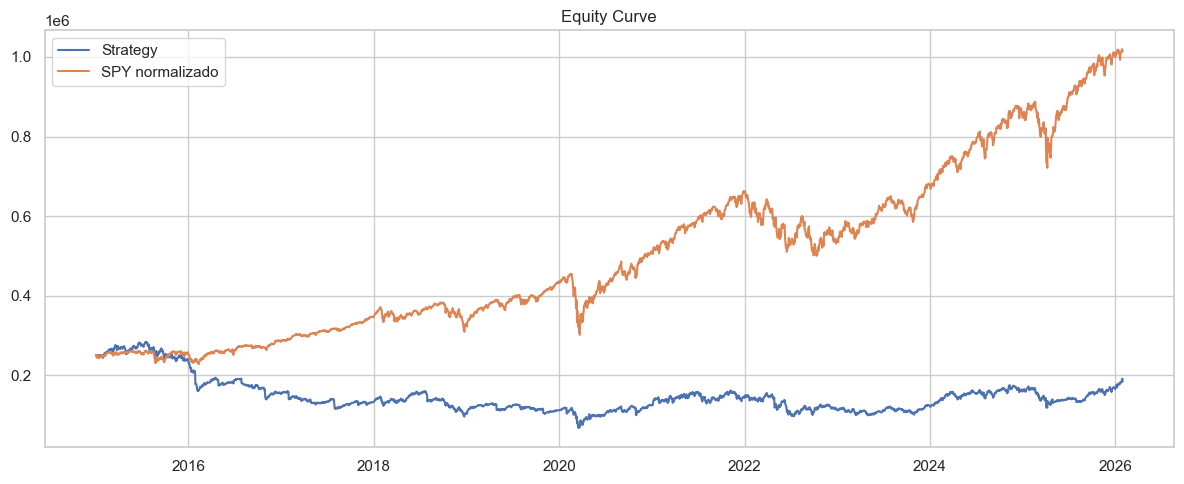

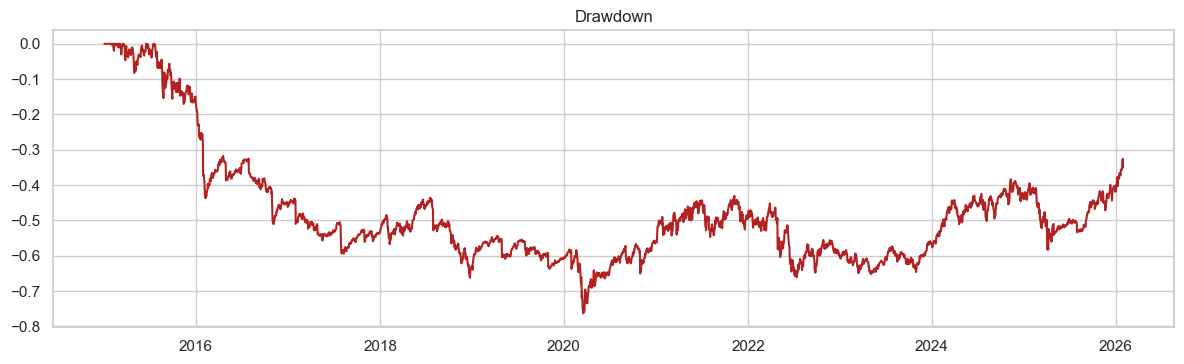

In [32]:
eq = equity_df["equity"].copy()
bench_norm = bench_close / bench_close.dropna().iloc[0] * eq.iloc[0]

plt.figure(figsize=(12, 5))
plt.plot(eq.index, eq.values, label="Strategy")
plt.plot(bench_norm.index, bench_norm.values, label="SPY normalizado")
plt.title("Equity Curve")
plt.legend()
plt.tight_layout()
plt.show()

dd = eq / eq.cummax() - 1
plt.figure(figsize=(12, 3.8))
plt.plot(dd.index, dd.values, color="firebrick")
plt.title("Drawdown")
plt.tight_layout()
plt.show()

## Analisis critico (resumen)
- La comisi?n m?nima de 23$ penaliza m?s a ?rdenes peque?as.
- Puede haber sesgo de supervivencia seg?n el universo heredado de NB1/NB2.
- El motor evita look-ahead usando solo OPEN/CLOSE de D o ?ltimo CLOSE <= D.
- No se modela slippage ni impacto de mercado (limitaci?n).

## Validacion y debug opcional (legacy)


## Resumen corto
- El flujo principal del notebook ya usa el FIX canonico de escala OPEN/CLOSE.
- El backtest oficial corre con control de coste minimo y cap diario de peso por posicion.
- La seccion de debug queda como validacion opcional para investigar desviaciones.


## Reconciliacion de retornos (motor vs datos)
